# Deep Learning 4 

## Requisitos mínimos para um pipeline de treino

Link Colab

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ftl-brazil-2026/ebook/blob/main/ml-dl/dl4_pipeline_de_treino.ipynb)

Nas aulas 1 a 3 vimos cada peça separada: a rede (função), a perda, o `backward()` e o otimizador. Hoje
montamos o **pipeline completo**, do dado bruto até o modelo treinado e avaliado, do jeito que se faz em
projetos de verdade:

1. `Dataset` e `DataLoader`: como o PyTorch entrega os dados para a rede
2. Treino, validação e teste: para que serve cada um
3. O laço de treino e o laço de avaliação em PyTorch puro
4. Primeiro contato com o ***overfitting***
5. Avaliação final no teste
6. O mesmo pipeline com **PyTorch Lightning**, sem esconder nada

In [1]:
# no Google Colab, o PyTorch já vem instalado; o Lightning não
import sys
if "google.colab" in sys.modules:
    !pip install -q lightning

In [2]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, random_split
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# cores e estilo dos gráficos (as mesmas das aulas de Machine Learning)
AZUL, LARANJA, VERDE, CINZA, TINTA = "#2a78d6", "#eb6834", "#1baf7a", "#898781", "#52514e"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": CINZA, "axes.labelcolor": TINTA,
    "xtick.color": TINTA, "ytick.color": TINTA,
    "axes.grid": True, "grid.color": "#e6e5e1", "figure.dpi": 110,
})

torch.manual_seed(42)

# CPU é mais rápida que a GPU do Mac (MPS) para uma rede tão pequena; no Colab com GPU, usamos CUDA
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cpu'

## 1. `Dataset`: como pegar **uma** amostra

Um `Dataset` do PyTorch é qualquer objeto que saiba responder duas perguntas:

- `__len__`: quantas amostras existem?
- `__getitem__(i)`: qual é a amostra número `i`? (devolve a entrada e o rótulo)

Só isso. Para entender, vamos escrever o nosso próprio `Dataset` a partir dos arrays brutos do MNIST
(imagens em `uint8`, de 0 a 255):

In [3]:
mnist_bruto = datasets.MNIST(root="data", train=True, download=True)
print(f"imagens: {tuple(mnist_bruto.data.shape)} {mnist_bruto.data.dtype}   rótulos: {tuple(mnist_bruto.targets.shape)}")

class DigitosDataset(Dataset):
    def __init__(self, imagens, rotulos):
        self.imagens = imagens          # (N, 28, 28), uint8 de 0 a 255
        self.rotulos = rotulos          # (N,)

    def __len__(self):
        return len(self.rotulos)

    def __getitem__(self, i):
        x = self.imagens[i].float().div(255).unsqueeze(0)   # (1, 28, 28), float de 0 a 1
        y = self.rotulos[i]
        return x, y

meu_dataset = DigitosDataset(mnist_bruto.data, mnist_bruto.targets)
x0, y0 = meu_dataset[0]
print(f"len = {len(meu_dataset)}   amostra 0: x {tuple(x0.shape)}, y = {y0.item()}")

imagens: (60000, 28, 28) torch.uint8   rótulos: (60000,)
len = 60000   amostra 0: x (1, 28, 28), y = 5


O `datasets.MNIST` do `torchvision` que usamos nas aulas anteriores é **exatamente** isso: uma classe com
`__len__` e `__getitem__`, mais o download e o `transform` (`ToTensor()` faz a mesma conversão de 0–255 para 0–1).
Daqui em diante usamos a versão pronta:

In [4]:
treino_completo = datasets.MNIST(root="data", train=True, download=True, transform=transforms.ToTensor())
teste = datasets.MNIST(root="data", train=False, download=True, transform=transforms.ToTensor())

x_tv, y_tv = treino_completo[0]
print(f"mesma amostra? {torch.equal(x_tv, x0) and y_tv == y0.item()}")

mesma amostra? True


## 2. `DataLoader`: lotes e embaralhamento

O `Dataset` entrega uma amostra por vez; o `DataLoader` junta várias em um **lote** (*batch*) e, se pedirmos,
**embaralha** a ordem a cada época. Embaralhar evita que a rede veja sempre a mesma sequência (por exemplo,
todos os "0" juntos), o que atrapalharia a descida do gradiente estocástica.

In [5]:
carregador = DataLoader(treino_completo, batch_size=64, shuffle=True)
x_lote, y_lote = next(iter(carregador))
print(f"um lote: x {tuple(x_lote.shape)}   y {tuple(y_lote.shape)}")
print(f"lotes por época: {len(carregador)}  (60000 / 64, arredondado para cima)")

print(f"\nrótulos do 1º lote, 1ª vez:  {next(iter(carregador))[1][:12].tolist()}")
print(f"rótulos do 1º lote, 2ª vez:  {next(iter(carregador))[1][:12].tolist()}  ← nova ordem a cada época")

um lote: x (64, 1, 28, 28)   y (64,)
lotes por época: 938  (60000 / 64, arredondado para cima)

rótulos do 1º lote, 1ª vez:  [9, 9, 4, 7, 7, 9, 4, 7, 9, 1, 7, 5]
rótulos do 1º lote, 2ª vez:  [6, 4, 7, 6, 7, 8, 8, 1, 3, 6, 7, 9]  ← nova ordem a cada época


## 3. Treino, validação e teste

| Conjunto | Tamanho | Para que serve | Quantas vezes usamos |
|---|---|---|---|
| **Treino** | 50.000 | ajustar os **pesos** (`backward()` + `step()`) | a cada passo |
| **Validação** | 10.000 | acompanhar o treino e escolher **hiperparâmetros** (lr, nº de épocas, tamanho da rede) | a cada época |
| **Teste** | 10.000 | estimar o desempenho em dados **novos** | **uma única vez**, no final |

Se escolhermos hiperparâmetros olhando o teste, ele deixa de ser "dado novo" e a nota fica otimista (a mesma
ideia de *data leakage* da aula de ML supervisionado).

O MNIST já vem com um teste separado (10 mil imagens). Separamos as 60 mil de treino em 50 mil + 10 mil com
`random_split`. Aqui um sorteio aleatório é adequado porque as imagens são **independentes** entre si. Na aula da
balneabilidade, com dados **temporais**, precisávamos separar pelo tempo.

In [6]:
gerador = torch.Generator().manual_seed(42)        # divisão reprodutível
treino, validacao = random_split(treino_completo, [50000, 10000], generator=gerador)

carregador_treino = DataLoader(treino, batch_size=64, shuffle=True, generator=torch.Generator().manual_seed(0))
carregador_val = DataLoader(validacao, batch_size=1000)     # sem embaralhar: a ordem não importa na avaliação
carregador_teste = DataLoader(teste, batch_size=1000)

print(f"treino: {len(treino)}   validação: {len(validacao)}   teste: {len(teste)}")

treino: 50000   validação: 10000   teste: 10000


## 4. O laço de treino em PyTorch puro

Duas funções, que vamos reaproveitar até o fim da aula:

- `treina_uma_epoca`: para cada lote, **forward → perda → backward → step** (o padrão da aula 3).
- `avalia`: calcula perda e acurácia **sem treinar**. Duas linhas novas:
  - `modelo.eval()` coloca a rede em modo de avaliação (desliga camadas que se comportam diferente no treino,
    como *Dropout* e *BatchNorm*; o nosso MLP não tem, mas é um hábito obrigatório). `modelo.train()` volta ao modo de treino.
  - `torch.no_grad()` desliga o *autograd*: não vamos chamar `backward()`, então não precisamos registrar as
    operações. Fica mais rápido e gasta menos memória.

In [7]:
def cria_mlp(escondida=128):
    return nn.Sequential(nn.Flatten(), nn.Linear(784, escondida), nn.ReLU(), nn.Linear(escondida, 10))


def treina_uma_epoca(modelo, carregador, otimizador):
    modelo.train()                                   # modo de treino
    soma_perda, acertos, total = 0.0, 0, 0
    for x, y in carregador:                          # para cada lote...
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = modelo(x)                           # 1. forward
        perda = F.cross_entropy(logits, y)           # 2. perda
        otimizador.zero_grad()                       # 3. zera gradientes
        perda.backward()                             # 4. backward
        otimizador.step()                            # 5. atualiza os pesos
        soma_perda += perda.item() * len(y)
        acertos += (logits.argmax(dim=1) == y).sum().item()
        total += len(y)
    return soma_perda / total, acertos / total


@torch.no_grad()                                     # desliga o autograd na função inteira
def avalia(modelo, carregador):
    modelo.eval()                                    # modo de avaliação
    soma_perda, acertos, total = 0.0, 0, 0
    for x, y in carregador:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = modelo(x)
        soma_perda += F.cross_entropy(logits, y, reduction="sum").item()
        acertos += (logits.argmax(dim=1) == y).sum().item()
        total += len(y)
    return soma_perda / total, acertos / total

In [8]:
torch.manual_seed(0)
modelo = cria_mlp().to(DEVICE)
otimizador = torch.optim.Adam(modelo.parameters(), lr=1e-3)
EPOCAS = 5

historico = []
inicio = time.time()
for epoca in range(1, EPOCAS + 1):                   # para cada época...
    perda_tr, acc_tr = treina_uma_epoca(modelo, carregador_treino, otimizador)
    perda_val, acc_val = avalia(modelo, carregador_val)
    historico.append({"época": epoca, "perda treino": perda_tr, "perda validação": perda_val,
                      "acurácia treino": acc_tr, "acurácia validação": acc_val})
    print(f"época {epoca}: perda treino = {perda_tr:.3f}  perda val = {perda_val:.3f}  "
          f"acc treino = {acc_tr:.2%}  acc val = {acc_val:.2%}")
print(f"\ntempo total: {time.time() - inicio:.0f} s")
historico = pd.DataFrame(historico).set_index("época")

época 1: perda treino = 0.364  perda val = 0.220  acc treino = 90.32%  acc val = 93.57%


época 2: perda treino = 0.172  perda val = 0.159  acc treino = 95.04%  acc val = 95.23%


época 3: perda treino = 0.122  perda val = 0.137  acc treino = 96.42%  acc val = 96.13%


época 4: perda treino = 0.093  perda val = 0.115  acc treino = 97.26%  acc val = 96.46%


época 5: perda treino = 0.075  perda val = 0.112  acc treino = 97.78%  acc val = 96.52%

tempo total: 5 s


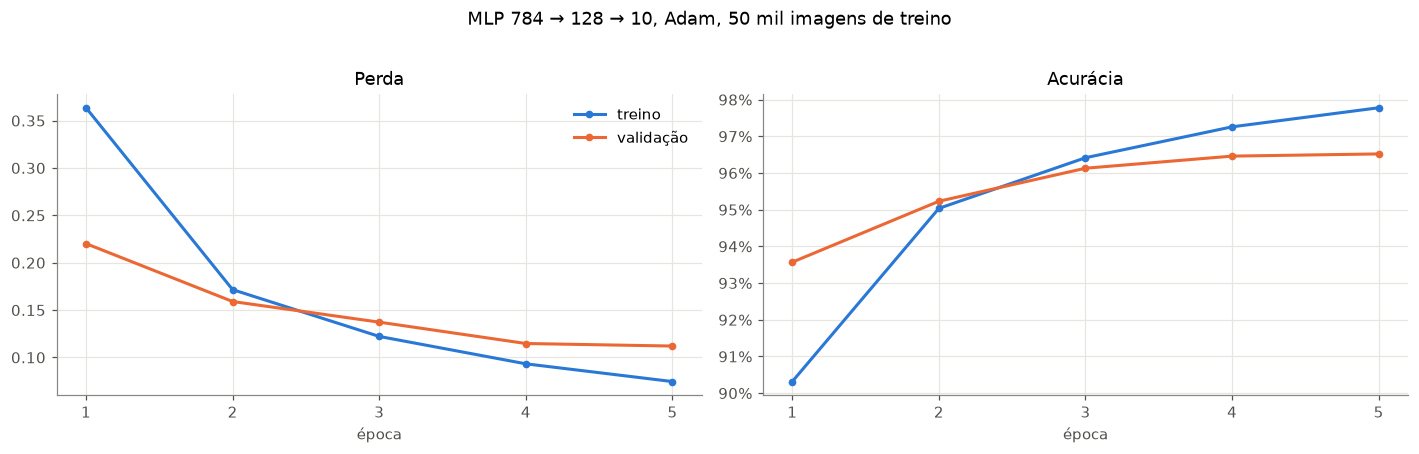

In [9]:
def plota_curvas(hist, titulo, marca=None):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, metrica in zip(axes, ["perda", "acurácia"]):
        ax.plot(hist.index, hist[f"{metrica} treino"], color=AZUL, lw=2, marker="o", ms=4, label="treino")
        ax.plot(hist.index, hist[f"{metrica} validação"], color=LARANJA, lw=2, marker="o", ms=4, label="validação")
        if marca is not None:
            ax.axvline(marca, color=CINZA, ls="--", lw=1)
        ax.set(xlabel="época", title=metrica.capitalize())
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    axes[1].yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
    axes[0].legend(frameon=False)
    plt.suptitle(titulo, y=1.02)
    plt.tight_layout()
    plt.show()

plota_curvas(historico, "MLP 784 → 128 → 10, Adam, 50 mil imagens de treino")

As duas curvas andam juntas: a rede melhora no treino **e** em dados que não usou para ajustar os pesos. É
o comportamento saudável.

Por que na época 1 a validação é *melhor* que o treino? A perda de treino é a **média ao longo da época**,
incluindo os primeiros lotes, quando a rede ainda chutava. A validação é medida **no fim** da época, com a rede
já treinada naquela época inteira.

## 5. Primeiro contato com o *overfitting*

O que acontece se a rede for **grande** e os dados de treino forem **poucos**? Vamos treinar uma rede bem maior
(784 → 512 → 10, com ~407 mil parâmetros) com apenas **1.000 imagens** de treino, por 60 épocas. A validação
continua com as mesmas 10 mil imagens.

In [10]:
poucas = Subset(treino, range(1000))
carregador_poucas = DataLoader(poucas, batch_size=64, shuffle=True, generator=torch.Generator().manual_seed(0))

torch.manual_seed(0)
modelo_grande = cria_mlp(escondida=512).to(DEVICE)
print(f"parâmetros: {sum(p.numel() for p in modelo_grande.parameters()):,} para {len(poucas)} imagens de treino")
otimizador_grande = torch.optim.Adam(modelo_grande.parameters(), lr=1e-3)

hist_overfit = []
for epoca in range(1, 61):
    perda_tr, acc_tr = treina_uma_epoca(modelo_grande, carregador_poucas, otimizador_grande)
    perda_val, acc_val = avalia(modelo_grande, carregador_val)
    hist_overfit.append({"época": epoca, "perda treino": perda_tr, "perda validação": perda_val,
                         "acurácia treino": acc_tr, "acurácia validação": acc_val})
hist_overfit = pd.DataFrame(hist_overfit).set_index("época")

melhor_epoca = hist_overfit["perda validação"].idxmin()
print(f"menor perda de validação na época {melhor_epoca}: {hist_overfit.loc[melhor_epoca, 'perda validação']:.3f}")
print(f"época 60: perda treino = {hist_overfit['perda treino'].iloc[-1]:.4f}   perda validação = {hist_overfit['perda validação'].iloc[-1]:.3f}")
print(f"época 60: acurácia treino = {hist_overfit['acurácia treino'].iloc[-1]:.1%}   acurácia validação = {hist_overfit['acurácia validação'].iloc[-1]:.1%}")

parâmetros: 407,050 para 1000 imagens de treino


menor perda de validação na época 11: 0.386
época 60: perda treino = 0.0014   perda validação = 0.486
época 60: acurácia treino = 100.0%   acurácia validação = 89.6%


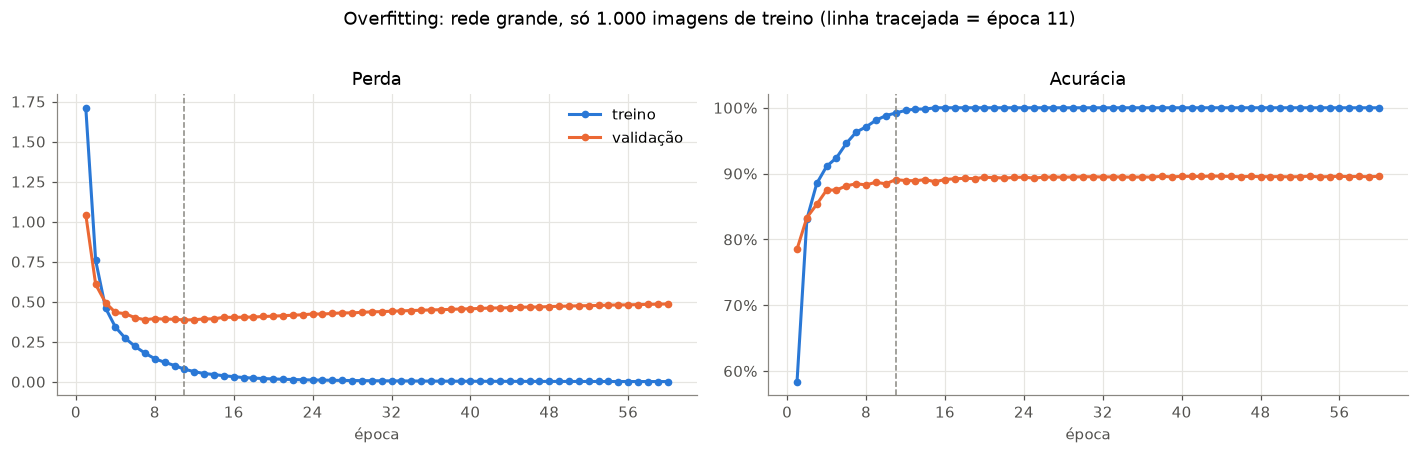

In [11]:
plota_curvas(hist_overfit, f"Overfitting: rede grande, só 1.000 imagens de treino (linha tracejada = época {melhor_epoca})",
             marca=melhor_epoca)

**Isso é *overfitting* (sobreajuste):**

- a perda de **treino** cai até quase zero e a acurácia de treino chega a 100%: a rede **decorou** as 1.000 imagens;
- a perda de **validação** para de cair (linha tracejada) e depois **sobe**: a rede fica cada vez mais confiante
  em respostas que não generalizam;
- a acurácia de validação **estaciona** em ~90%, bem abaixo dos ~97% da seção 4: com 1.000 imagens a rede não
  tem exemplos suficientes para generalizar, por maior que seja.

Sem um conjunto de validação, só veríamos a curva azul e acharíamos que o modelo está ótimo. A validação mostra
**quando parar** (a ideia do *early stopping*). Outras armas contra o overfitting: mais dados, redes menores e
regularização (*dropout*, *weight decay*), que veremos mais adiante.

## 6. Avaliação final no teste

Voltamos ao modelo da seção 4 (50 mil imagens, 5 épocas) e usamos o teste **uma única vez**.

In [12]:
perda_teste, acc_teste = avalia(modelo, carregador_teste)
print(f"TESTE: perda = {perda_teste:.3f}   acurácia = {acc_teste:.2%}")

@torch.no_grad()
def predicoes(modelo, carregador):
    modelo.eval()
    ys, preds = [], []
    for x, y in carregador:
        preds.append(modelo(x.to(DEVICE)).argmax(dim=1).cpu())
        ys.append(y)
    return torch.cat(ys), torch.cat(preds)

y_teste, pred_teste = predicoes(modelo, carregador_teste)

TESTE: perda = 0.097   acurácia = 97.22%


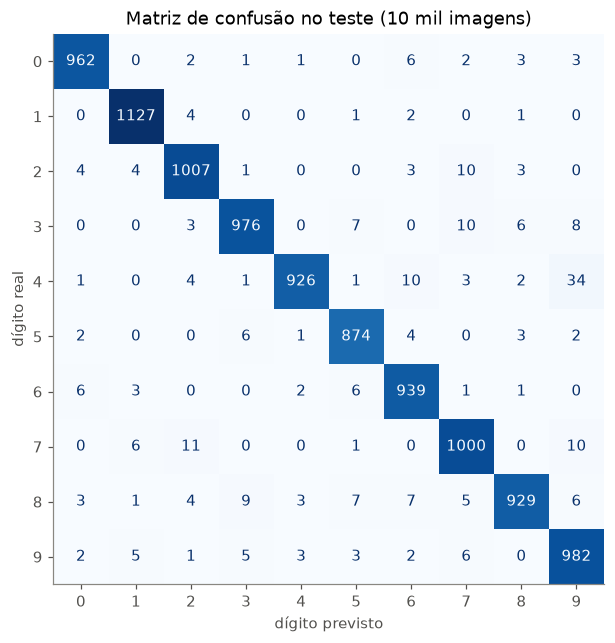

In [13]:
fig, ax = plt.subplots(figsize=(7.5, 6.5))
ConfusionMatrixDisplay(confusion_matrix(y_teste, pred_teste)).plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set(xlabel="dígito previsto", ylabel="dígito real", title="Matriz de confusão no teste (10 mil imagens)")
ax.grid(False)
plt.show()

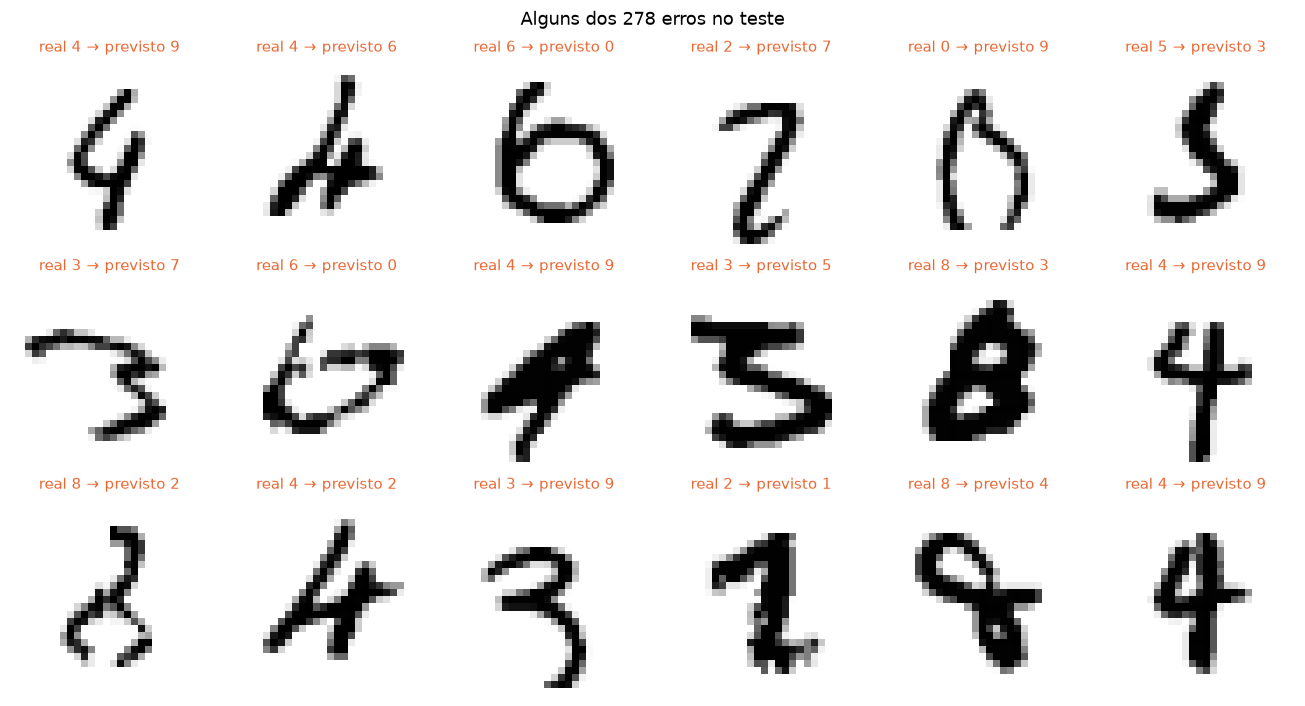

In [14]:
erros = torch.nonzero(pred_teste != y_teste).flatten()[:18]
fig, axes = plt.subplots(3, 6, figsize=(12, 6.5))
for ax, i in zip(axes.flat, erros):
    ax.imshow(teste[i][0][0], cmap="gray_r")
    ax.set_title(f"real {y_teste[i].item()} → previsto {pred_teste[i].item()}", color=LARANJA, fontsize=10)
    ax.axis("off")
plt.suptitle(f"Alguns dos {(pred_teste != y_teste).sum().item()} erros no teste")
plt.tight_layout()
plt.show()

Muitos erros são dígitos que até um humano hesitaria em classificar. Para ir além de ~97–98% em imagens,
precisamos de redes que **entendam a estrutura espacial** da imagem (vizinhança entre pixels), em vez de
achatá-la em um vetor: as **redes convolucionais**, assunto das próximas aulas.

## 7. O mesmo pipeline com PyTorch Lightning

Todo projeto em PyTorch acaba reescrevendo as mesmas coisas: o laço de épocas, `model.train()`/`model.eval()`,
`torch.no_grad()`, mover dados para a GPU, registrar métricas, salvar *checkpoints*... O **PyTorch Lightning**
organiza esse código padrão para você. **Você continua escrevendo PyTorch**: só coloca cada pedaço em um método
com nome fixo, e o `Trainer` executa o laço.

Um `LightningModule` tem quatro métodos principais:

- `forward`: a rede (aula 1);
- `training_step`: o que fazer com **um lote** de treino; devolve a perda;
- `validation_step` / `test_step`: o que fazer com um lote de validação/teste;
- `configure_optimizers`: qual otimizador usar (aula 3).

In [15]:
import lightning as L
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.utilities.model_summary import ModelSummary
import logging

# deixa a saída do Lightning mais limpa na aula
logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", ".*does not have many workers.*")
warnings.filterwarnings("ignore", ".*GPU available but not used.*")     # a GPU do Mac (MPS), que não usamos aqui
warnings.filterwarnings("ignore", ".*LeafSpec.*")                       # aviso interno do Lightning


class MLPMnist(L.LightningModule):
    def __init__(self, escondida=128, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()                         # guarda escondida e lr junto com o modelo
        self.rede = cria_mlp(escondida)

    def forward(self, x):
        return self.rede(x)

    def _passo(self, lote, etapa):
        x, y = lote
        logits = self(x)                                    # forward
        perda = F.cross_entropy(logits, y)                  # perda
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log(f"{etapa}_perda", perda, on_step=False, on_epoch=True)
        self.log(f"{etapa}_acc", acc, on_step=False, on_epoch=True)
        return perda

    def training_step(self, lote, indice):
        return self._passo(lote, "treino")                  # o Lightning faz backward() e step() com a perda devolvida

    def validation_step(self, lote, indice):
        self._passo(lote, "val")

    def test_step(self, lote, indice):
        self._passo(lote, "teste")

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)


torch.manual_seed(0)
modelo_l = MLPMnist()
print(ModelSummary(modelo_l))

  | Name | Type       | Params | Mode  | FLOPs
----------------------------------------------------
0 | rede | Sequential | 101 K  | train | 0    
----------------------------------------------------
101 K     Trainable params
0         Non-trainable params
101 K     Total params
0.407     Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode
0         Total Flops


In [16]:
trainer = L.Trainer(
    max_epochs=5,                                           # o laço de épocas
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    logger=CSVLogger("logs", name="mlp_mnist"),             # salva as métricas em um CSV
    enable_progress_bar=False,
    enable_checkpointing=False,
)
inicio = time.time()
trainer.fit(modelo_l, carregador_treino, carregador_val)    # treino + validação a cada época
print(f"tempo total: {time.time() - inicio:.0f} s")

tempo total: 7 s


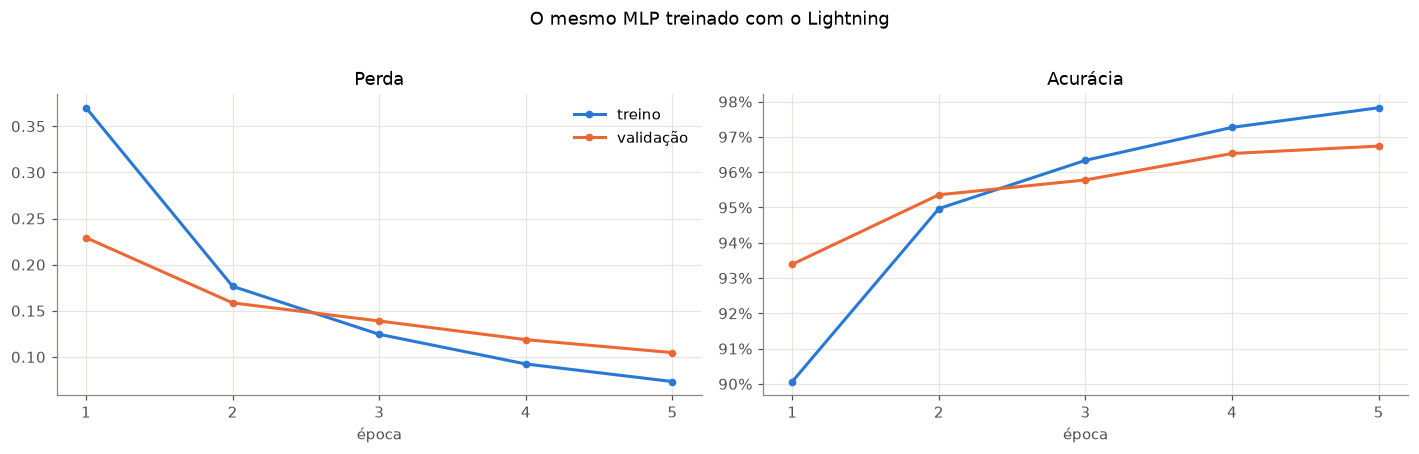

In [17]:
metricas_l = pd.read_csv(f"{trainer.logger.log_dir}/metrics.csv")
hist_l = metricas_l.groupby("epoch").first().rename(columns={
    "treino_perda": "perda treino", "val_perda": "perda validação",
    "treino_acc": "acurácia treino", "val_acc": "acurácia validação"})
hist_l.index = hist_l.index + 1
hist_l.index.name = "época"

plota_curvas(hist_l, "O mesmo MLP treinado com o Lightning")

In [18]:
resultado = trainer.test(modelo_l, carregador_teste, verbose=False)[0]
print(f"TESTE (Lightning):    perda = {resultado['teste_perda']:.3f}   acurácia = {resultado['teste_acc']:.2%}")
print(f"TESTE (PyTorch puro): perda = {perda_teste:.3f}   acurácia = {acc_teste:.2%}")

TESTE (Lightning):    perda = 0.087   acurácia = 97.40%
TESTE (PyTorch puro): perda = 0.097   acurácia = 97.22%


Os resultados ficam muito próximos dos do PyTorch puro, como esperado: é a **mesma rede, a mesma perda e o
mesmo otimizador**. (Não são idênticos porque a inicialização e a ordem dos lotes não são exatamente as mesmas.)

### Nada está escondido: onde foi parar cada linha?

| PyTorch puro (seção 4) | Lightning |
|---|---|
| `for epoca in range(EPOCAS):` | `Trainer(max_epochs=5)` |
| `for x, y in carregador_treino:` | `trainer.fit(modelo, carregador_treino, ...)` chama `training_step` para cada lote |
| `modelo.train()` / `modelo.eval()` | automático, antes do treino e da validação |
| `x, y = x.to(DEVICE), y.to(DEVICE)` | automático (`accelerator=...`) |
| `logits = modelo(x)` | `forward` |
| `perda = F.cross_entropy(logits, y)` | dentro de `training_step`, que **devolve** a perda |
| `otimizador.zero_grad()` → `perda.backward()` → `otimizador.step()` | automático, com a perda devolvida por `training_step` |
| `torch.optim.Adam(modelo.parameters(), lr=1e-3)` | `configure_optimizers` |
| `@torch.no_grad()` + laço da função `avalia` | `validation_step` / `test_step` (já sem gradiente) |
| `avalia(modelo, carregador_val)` a cada época | `trainer.fit(..., carregador_val)` |
| `historico.append(...)` e `print(...)` | `self.log(...)` + `CSVLogger` |
| `avalia(modelo, carregador_teste)` | `trainer.test(modelo, carregador_teste)` |

Escrever o laço à mão primeiro é o melhor jeito de aprender. Em projetos maiores, o Lightning poupa código
repetido e traz de graça treino em várias GPUs, *checkpoints*, *early stopping* e registro de métricas.

## 8. Discussão

- `Dataset` define **como pegar uma amostra**; `DataLoader` cuida dos **lotes** e do **embaralhamento**.
- **Treino** ajusta os pesos, **validação** acompanha o treino e escolhe hiperparâmetros, **teste** é usado uma
  única vez no final.
- O laço de treino é sempre: épocas → lotes → *forward* → perda → `zero_grad` → `backward` → `step`. A avaliação
  usa `model.eval()` e `torch.no_grad()`.
- **Overfitting** aparece quando a perda de treino continua caindo e a de validação sobe: a rede decorou o treino.
  As curvas de validação dizem quando parar.
- O **Lightning** organiza o mesmo código em métodos com nome fixo; o `Trainer` executa o laço.

### Exercícios

1. Na seção 5, troque 1.000 por 10.000 imagens de treino. O overfitting diminui? Em que época a perda de validação é mínima?
2. Adicione `nn.Dropout(0.5)` depois da `nn.ReLU()` da rede grande e repita a seção 5. O que muda nas curvas? (Por
   que agora `model.train()`/`model.eval()` fazem diferença?)
3. No Lightning, adicione o *callback* `L.pytorch.callbacks.EarlyStopping(monitor="val_perda", patience=3)` ao
   `Trainer` e treine a rede grande com 1.000 imagens por até 60 épocas. Em que época ele para?
4. Troque `cria_mlp` por uma rede com duas camadas escondidas (784 → 256 → 128 → 10). A acurácia no teste melhora?